# 第五章 PyTorch数值建模

数据建模即数值挖掘，对于数值型数据，它从大量数据中寻找其规律，分为数据准备、规律寻找和规律表示3个步骤。数据准备是从相关的数据源中选取所需的数据并整合成用于数据挖掘的数据集，规律寻找是用某种方法将数据集所含的规律找出来，规律表示是尽可能以用户可理解的方式将找出的规律表示出来。本章介绍PyTorch在数值建模中的应用。

## 5.1 回归分析及案例

回归分析是研究一个变量(被解释变量)与另一个或几个变量(解释变量)的具体依赖关系的计算方法和理论。本节介绍使用PyTorch进行回归分析。

### 5.1.1 回归分析简介

回归分析就是从一组样本数据出发，确定变量之间的数学关系式，并对这些关系式的可信程度进行各种统计检验，从影响某一特定变量的诸多变量中找出哪些变量的影响显著，哪些不显著。利用所求的关系式，根据一个或几个变量的取值来预测或控制另一个特定变量的取值，同时给出这种预测或控制的精确程度。

线性回归主要用来解决连续性数值预测的问题，它目前在经济、金融、社会、医疗等领域都有广泛的应用。例如，我们要研究有关吸烟对死亡率和发病率影响的早期证据来自采用了回归分析的观察性研究。为了在分析观测数据时减少伪相关，除最感兴趣的变量之外，通常研究人员还会在他们的回归模型中包括一些额外变量。例如，假设有一个回归模型，在这个回归模型中，吸烟行为是我们最感兴趣的独立变量，其相关变量是经数年观察得到的吸烟者寿命。

研究人员可能将社会经济地位当成一个额外的独立变量，以确保任何经观察所得的吸烟对寿命的影响不是由于教育或收入差异引起的。然而，我们不可能把所有可能混淆结果的变量都加入实证分析中。例如，某种不存在的基因可能会增加人死亡的概率，还会让人的吸烟量增加。因此，比起采用观察数据的回归分析得出的结论，随机对照试验常能产生更令人信服的因果关系证据。

此外，回归分析还在以下诸多方面得到了很好的应用:
* 客户需求预测:通过海量的买家和卖家交易数据等对未来商品的需求进行预测。
* 电影票房预测:通过历史票房数据、影评数据等公众数据对电影票房进行预测。
* 湖泊面积预测:通过研究湖泊面积变化的多种影响因素构建湖泊面积预测模型。
* 房地产价格预测:用相关历史数据分析影响商品房价格的因素并进行模型预测。
* 股价波动预测:公司在搜索引擎中的搜索量代表了该股票被投资者关注的程度。
* 人口增长预测:用历史数据分析影响人口增长的因素，对未来人口数进行预测。

### 5.1.2 回归分析建模

线性回归(Linear Regression)是利用回归方程(函数)对一个或多个自变量(特征值)和因变量(目标值)之间的关系进行建模的一种分析方式。线性回归就是用一条直线较为精确地描述数据之间的关系。这样当出现新的数据的时候，就能够预测出一个简单的值。线性回归中常见的就是房屋面积和房价的预测问题。只有一个自变量的情况称为一元回归，大于一个自变量的情况称为多元回归。

多元线性回归模型是日常工作中应用频繁的模型，公式如下:$y=\beta_0+\beta_1x_1+\beta_2x_2+···+\beta_kx_k+\epsilon$,其中，$x_1···x_k$是自变量，y是因变量，$\beta_0$是截距，$\beta_1···\beta_k$是变量回归系数，$\epsilon$是误差项的随机变量。

对于误差项有如下几个假设条件:
* 误差项$\epsilon$是一个期望为0的随机变量。
* 对于自变量的所有值，$\epsilon$的方差都相同。
* 误差项$\epsilon$是一个服从正态分布的随机变量，且相互独立。

如果想让我们的预测值尽量准确，就必须让真实值与预测值的差值最小，即让误差平方和最小，用公式来表达如下，具体推导过程可参考相关的资料。
$J(\beta)=\sum(y-X\beta)^2$

损失函数只是一种策略，有了策略，我们还要用适合的算法进行求解。在线性回归模型中，求解损失函数就是求与自变量相对应的各个回归系数和截距。有了这些参数，我们才能实现模型的预测(输入x，给出y)。

对于误差平方和损失函数的求解方法有很多，典型的如最小二乘法、梯度下降法等。因此，通过以上的异同点，总结如下:

最小二乘法的特点：
* 得到的是全局最优解，因为一步到位，直接求极值，所以步骤简单。
* 线性回归的模型假设，这是最小二乘方法的优越性前提，否则不能推出最小二乘是最佳(方差最小)的无偏估计。

梯度下降法的特点:
* 得到的是局部最优解，因为是一步一步迭代的，而非直接求得极值。
* 既可以用于线性模型，又可以用于非线性模型，没有特殊的限制和假设条件。
* 在回归分析过程中，还需要进行线性回归诊断，回归诊断是对回归分析中的假设以及数据的检验与分析，主要的衡量值是判定系数和估计标准误差。

1.判定系数

回归直线与各观测点的接近程度成为回归直线对数据的拟合优度。而评判直线拟合优度需要一些指标，其中一个就是判定系数。我们知道，因变量y值有来自两个方面的影响:
* 来自x值的影响，也就是我们预测的主要依据。
* 来自无法预测的干扰项$\epsilon$的影响。

如果一个回归直线预测得非常准确，它就需要让来自x的影响尽可能大，而让来自无法预测千扰项的影响尽可能小，也就是说x的影响占比越高，预测效果就越好。下面我们来看如何定义这些影响，并形成指标。

$SST = \sum(y_i-y_m)^2$

$SSR = \sum(\hat y_i-y_m)^2$

$SSE = \sum(y_i-\hat y_i)^2$
* $SST$(总平方和):总平方和,是衡量数据点与数据平均值之间总变异性的指标。
* $SSR$(回归平方和):由x与y之间的线性关系引起的y的变化，反映了回归值的分散程度。
* $SSE$(残差平方和):除x影响之外的其他因素引起的y的变化，反映了观测值偏离回归直线的程度。

总平方和、回归平方和、残差平方和三者之间的关系如下图所示。

![](data/img1.jpeg)

它们之间的关系是:SSR越高，则代表回归预测越准确，观测点越靠近直线，即越大，直线拟合越好。因此，判定系数的定义就自然地引出来了，我们一般称为$R^2$，公式为$R^2=\frac {SSR}{SST}=1-\frac{SSE}{SST}$。

2.估计标准误差

判定系数$R^2$的意义是由x引起的影响占总影响的比例来判断拟合程度的。当然，我们也可以从误差的角度去评估，也就是用残差SSE进行判断。估计标准误差是均方残差的平方根，可以度量实际观测点在直线周围散布的情况，公式为$S_{\epsilon}=\sqrt \frac{SSE}{n-2}=\sqrt{MSE}$。

估计标准误差与判定系数相反，S反映了预测值与真实值之间误差的大小。误差越小，就说明拟合度越高；相反，误差越大，就说明拟合度越低。

### 5.1.3 动手练习：住房价格回归预测

1.说明

本例利用深度学习的方法对某地的房价进行预测，销售者根据预测的结果选择适合自己的房屋。这里我们仅仅研究部分住房价格影响因素，如房屋的面积、户型、类型、配套设施、地理位置等，具体如表所示。

|字段名称|字段说明|
|:-:|:-:|
|Id|住房编号|
|Area|房屋面积|
|Shape|房屋户型|
|Style|房屋类型|
|Utilities|配套设施，如通不通水电气|
|Neighborhood|地理位置|
|Price|销售价格|

2.步骤

具体步骤如下：

1.导入相关第三方库

In [1]:
import warnings
warnings.filterwarnings("ignore")

import time
import torch
import numpy as np
import pandas as pd
from torch.utils.data import DataLoader,TensorDataset

strat = time.perf_counter()

2.读取训练数据和测试数据

In [2]:
o_train = pd.read_csv('./data/train.csv')
o_test = pd.read_csv('./data/test.csv')

In [3]:
o_train

,Id,Area,Shape,Style,Utilities,Neighborhood,Price
0,1,8450,Reg,2Story,AllPub,CollgCr,20850
1,2,9600,Reg,1Story,AllPub,Veenker,18150
2,3,11250,IR1,2Story,AllPub,CollgCr,22350
3,4,9550,IR1,2Story,AllPub,Crawfor,14000
4,5,14260,IR1,2Story,AllPub,NoRidge,25000
...,...,...,...,...,...,...,...
1309,1310,7153,Reg,1Story,AllPub,SawyerW,17920
1310,1311,17500,Reg,1Story,AllPub,Crawfor,33500
1311,1312,8814,Reg,1Story,AllPub,CollgCr,20300
1312,1313,9572,IR1,2Story,AllPub,NoRidge,30200


3.合并数据集

In [4]:
all_features = pd.concat((o_train.loc[:,'Area':'Neighborhood'],o_test.loc[:,'Area':'Neighborhood']))
all_labels = pd.concat((o_train.loc[:,'Price'],o_test.loc[:,'Price']))

In [5]:
all_features

,Area,Shape,Style,Utilities,Neighborhood
0,8450,Reg,2Story,AllPub,CollgCr
1,9600,Reg,1Story,AllPub,Veenker
2,11250,IR1,2Story,AllPub,CollgCr
3,9550,IR1,2Story,AllPub,Crawfor
4,14260,IR1,2Story,AllPub,NoRidge
...,...,...,...,...,...
4,14781,IR2,1Story,AllPub,CollgCr
5,10215,Reg,1Story,AllPub,Edwards
6,8400,Reg,1Story,AllPub,NAmes
7,6627,IR1,1Story,AllPub,BrkSide


In [6]:
all_labels

0    20850
1    18150
2    22350
3    14000
4    25000
     ...  
4    27500
5    11100
6    15650
7     7250
8    19000
Name: Price, Length: 1323, dtype: int64

4.数据预处理

In [7]:
numeric_feats = all_features.dtypes[all_features.dtypes != "object"].index
object_feats = all_features.dtypes[all_features.dtypes == "object"].index

In [8]:
numeric_feats

Index(['Area'], dtype='object')

In [9]:
object_feats

Index(['Shape', 'Style', 'Utilities', 'Neighborhood'], dtype='object')

In [10]:
a = all_features["Area"].values
a

array([ 8450,  9600, 11250, ...,  8400,  6627, 10186], dtype=int64)

In [11]:
np.max(a), np.min(a)

(215245, 1300)

In [12]:
all_features[numeric_feats] = all_features[numeric_feats].apply(lambda x: (x - x.mean()) / (x.std()))
all_features = pd.get_dummies(all_features,prefix=object_feats, dummy_na=True)
all_features = all_features.fillna(all_features.mean())

In [13]:
b = all_features["Area"].values
b

array([-0.20447089, -0.09290216,  0.06717473, ..., -0.20932171,
       -0.3813316 , -0.03605061])

In [14]:
b.max(), b.min()

(19.858013500604123, -0.8981373925440816)

In [15]:
all_features

,Area,Shape_IR1,Shape_IR2,Shape_IR3,Shape_Reg,Shape_nan,Style_1.5Fin,Style_1.5Unf,Style_1Story,Style_2.5Fin,...,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Neighborhood_nan
0,-0.204471,False,False,False,True,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
1,-0.092902,False,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,True,False
2,0.067175,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
3,-0.097753,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
4,0.359194,True,False,False,False,False,False,False,False,False,...,False,False,False,False,False,False,False,False,False,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4,0.409739,False,True,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
5,-0.033237,False,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
6,-0.209322,False,False,False,True,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False
7,-0.381332,True,False,False,False,False,False,False,True,False,...,False,False,False,False,False,False,False,False,False,False


In [16]:
mean = all_labels.mean()
std = all_labels.std()
all_labels = (all_labels - mean)/std

In [17]:
num_train = o_train.shape[0]
train_features = all_features[:num_train].values.astype(np.float32)
test_features = all_features[num_train:].values.astype(np.float32)
train_labels = all_labels[:num_train].values.astype(np.float32)
test_labels = all_labels[num_train:].values.astype(np.float32)

5.数据类型转换，数组转换成张量

In [18]:
train_features = torch.from_numpy(train_features)
train_labels = torch.from_numpy(train_labels).unsqueeze(1)
test_features = torch.from_numpy(test_features)
test_labels = torch.from_numpy(test_labels).unsqueeze(1)
train_set = TensorDataset(train_features,train_labels)
test_set = TensorDataset(test_features,test_labels)

In [19]:
train_features.shape

torch.Size([1314, 44])

In [20]:
train_labels.shape

torch.Size([1314, 1])

6.设置数据迭代器

In [21]:
train_data = DataLoader(dataset=train_set,batch_size=64,shuffle=True)
test_data = DataLoader(dataset=test_set,batch_size=64,shuffle=False)

7.设置网络结构

In [22]:
class Net(torch.nn.Module):
    def __init__(self, n_feature, n_output):
        super(Net, self).__init__()
        self.layer1 = torch.nn.Linear(n_feature, 600)
        self.layer2 = torch.nn.Linear(600, 1200)
        self.layer3 = torch.nn.Linear(1200, 1200)
        self.layer4 = torch.nn.Linear(1200, n_output)
        
    def forward(self, x):
        x = self.layer1(x)
        x = torch.relu(x)
        x = self.layer2(x)
        x = torch.relu(x)
        x = self.layer3(x)
        x = torch.relu(x)
        x = self.layer4(x)
        return x
net = Net(44,1)

In [23]:
net

Net(
  (layer1): Linear(in_features=44, out_features=600, bias=True)
  (layer2): Linear(in_features=600, out_features=1200, bias=True)
  (layer3): Linear(in_features=1200, out_features=1200, bias=True)
  (layer4): Linear(in_features=1200, out_features=1, bias=True)
)

In [25]:
optimizer = torch.optim.Adam(net.parameters(), lr=1e-4)
criterion = torch.nn.MSELoss()

8.模型训练

In [26]:
losses = []
eval_losses = []
for i in range(200):
    train_loss = 0
    net.train()
    for tdata,tlabel in train_data:
        y_ = net(tdata)
        loss = criterion(y_, tlabel)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        train_loss = train_loss + loss.item()
    losses.append(train_loss / len(train_data))
    eval_loss = 0
    net.eval()
    for edata, elabel in test_data:
        y_ = net(edata)
        loss = criterion(y_, elabel)
        eval_loss = eval_loss + loss.item()
    eval_losses.append(eval_loss / len(test_data))
    print('训练次数: {}, 训练集损失: {}, 测试集损失: {}'.format(i, train_loss / len(train_data), eval_loss / len(test_data)))

训练次数: 0, 训练集损失: 0.873151075272333, 测试集损失: 0.5960456728935242
训练次数: 1, 训练集损失: 0.627507338921229, 测试集损失: 0.5077375769615173
训练次数: 2, 训练集损失: 0.4923312479541415, 测试集损失: 0.5070931315422058
训练次数: 3, 训练集损失: 0.39188424746195477, 测试集损失: 0.6155371069908142
训练次数: 4, 训练集损失: 0.3697876738650458, 测试集损失: 0.5677803754806519
训练次数: 5, 训练集损失: 0.35471766761371065, 测试集损失: 0.6242100596427917
训练次数: 6, 训练集损失: 0.3284862197580792, 测试集损失: 0.5850964784622192
训练次数: 7, 训练集损失: 0.32293805692877087, 测试集损失: 0.6202561259269714
训练次数: 8, 训练集损失: 0.3164519781158084, 测试集损失: 0.6380955576896667
训练次数: 9, 训练集损失: 0.31603224930309115, 测试集损失: 0.5731308460235596
训练次数: 10, 训练集损失: 0.29560802451201845, 测试集损失: 0.6092559695243835
训练次数: 11, 训练集损失: 0.3002227402868725, 测试集损失: 0.6781675815582275
训练次数: 12, 训练集损失: 0.29644151457718443, 测试集损失: 0.6325291991233826
训练次数: 13, 训练集损失: 0.28608991489523933, 测试集损失: 0.5608814358711243
训练次数: 14, 训练集损失: 0.27507931277865455, 测试集损失: 0.5771632194519043
训练次数: 15, 训练集损失: 0.2714046381768726, 测试集损失: 0.5301215052604

训练次数: 129, 训练集损失: 0.1763056775643712, 测试集损失: 0.5764577388763428
训练次数: 130, 训练集损失: 0.17666868475221453, 测试集损失: 0.49175718426704407
训练次数: 131, 训练集损失: 0.17406977535713286, 测试集损失: 0.5456849336624146
训练次数: 132, 训练集损失: 0.18007478224379675, 测试集损失: 0.5177719593048096
训练次数: 133, 训练集损失: 0.1740133748168037, 测试集损失: 0.524604082107544
训练次数: 134, 训练集损失: 0.17208723759367353, 测试集损失: 0.5253996253013611
训练次数: 135, 训练集损失: 0.17633560264394396, 测试集损失: 0.5208134651184082
训练次数: 136, 训练集损失: 0.17476921741451537, 测试集损失: 0.5363953709602356
训练次数: 137, 训练集损失: 0.1692050684775625, 测试集损失: 0.5197290778160095
训练次数: 138, 训练集损失: 0.17341970013720648, 测试集损失: 0.518531322479248
训练次数: 139, 训练集损失: 0.16858775878236407, 测试集损失: 0.5220721960067749
训练次数: 140, 训练集损失: 0.1696707024460747, 测试集损失: 0.5356200337409973
训练次数: 141, 训练集损失: 0.17267801044952302, 测试集损失: 0.5367333889007568
训练次数: 142, 训练集损失: 0.1780520553390185, 测试集损失: 0.5847224593162537
训练次数: 143, 训练集损失: 0.17212495030391783, 测试集损失: 0.5125235319137573
训练次数: 144, 训练集损失: 0.17211520813

9.模型评估与预测

In [35]:
y_ = net(test_features)
y_pre = y_ * std + mean
print('测试集预测值：',y_pre.squeeze().detach().cpu().numpy())
print('模型平均误差：',abs(y_pre - (test_labels*std + mean)).mean().cpu().item() )
end =time.perf_counter()
print('模型运行时间：',end - strat)

测试集预测值： [11747.3125 15972.848  20909.451  16529.709  17288.072  12036.044
 13032.502   9692.907  27575.934 ]
模型平均误差： 4733.8876953125
模型运行时间： 1912.0010455000156


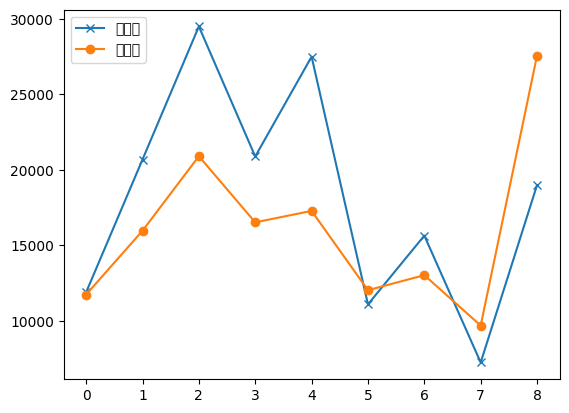

In [36]:
import matplotlib.pyplot as plt
plt.plot((test_labels*std + mean).detach().numpy(), label = "实际值", marker = "x")
plt.plot(y_pre.squeeze().detach().cpu().numpy(),label = "预测值", marker = "o")
plt.legend(loc = "best")
plt.show()

## 5.2 聚类分析及案例

聚类分析是一种探索性的分析，在分类的过程中，人们不必事先给出一个分类的标准，聚类分析能够从样本数据出发，自动进行分类。本节介绍使用PyTorch进行聚类分析及其案例。

### 5.2.1 聚类分析简介

聚类分析是根据事物本身的特性研究个体的一种方法，目的在于将相似的事物归类。它的原则是同一类中的个体有较大的相似性，不同类别之间的个体差异性很大。聚类算法的特征如下:
* 适用于没有先验知识的分类。如果没有这些事先的经验或一些国际标准、国内标准、行业标准，分类便会显得随意和主观。这时只要设定比较完善的分类变量，就可以通过聚类分析法得到较为科学合理的类别。
* 可以处理多个变量决定的分类。例如，根据消费者购买量的大小进行分类比较容易，但如果在进行数据挖掘时，要求根据消费者的购买量、家庭收入、家庭支出、年龄等多个指标进行分类，通常比较复杂，而聚类分析法可以解决这类问题。
* 是一种探索性分析方法，能够分析事物的内在特点和规律，并根据相似性原则对事物进行分组，是数据挖掘中常用的一种技术。

聚类分析被应用于很多方面，在商业上，聚类分析被用来发现不同的客户群，并且通过购买模式刻画不同的客户群特征;在生物领域，聚类分析被用来对动植物进行分类和对基因进行分类，获取对种群固有结构的认识;在保险行业上，聚类分析通过一个高的平均消费来鉴定汽车保险单持有者的分组，同时根据住宅类型、价值、地理位置来鉴定一个城市的房产分组;在互联网应用上，聚类分析被用来在网上进行文档归类来修复信息。

### 5.2.2 聚类分析建模

一般聚类分析的建模步骤如下：

(1) 数据预处理

数据预处理包括选择数量、类型和特征的标度，它依靠特征选择和特征抽取:特征选择是选择重要的特征，特征抽取是把输入的特征转化为一个新的显著特征，它们经常被用来获取一个合适的特征集来为避免“维数灾难”进行聚类。数据预处理还包括将孤立点移出数据，孤立点是不依附于一般数据行为或模型的数据，因此孤立点经常会导致有偏差的聚类结果，为了得到正确的聚类，我们必须将它们剔除。

(2) 为衡量数据点间的相似度定义一个距离函数

既然相似性是定义一个类的基础，那么不同数据之间在同一个特征空间相似度的衡量对于聚类步骤是很重要的，由于特征类型和特征标度的多样性，距离度量必须谨慎，它经常依赖于应用。例如，通常通过定义在特征空间的距离度量来评估不同对象的相异性，很多距离度量都应用在一些不同的领域，一个简单的距离度量，如欧氏距离，经常被用作反映不同数据间的相异性。

常用来衡量数据点间的相似度的距离有海明距离、欧氏距离、马氏距离等，公式如下:

海明距离：$d(x_i, x_j)=\sum _{k=1}^m|x_{ik}-x_{j_k}|$

欧式距离：$d(x_i, x_j)=\sqrt {\sum _{k=1}^m(x_{ik}-x_{j_k})^2}$

马氏距离：$d(x_i, x_j)=\sqrt {(x_i-x_j)^T\sum^{-1}(x_i-x_j)}$

(3) 聚类或分组

将数据对象分到不同的类中是一个很重要的步骤，数据基于不同的方法被分到不同的类中。划分方法和层次方法是聚类分析的两个主要方法。划分方法一般从初始划分和最优化一个聚类标准开始，主要方法包括:

* Crisp Clustering:它的每个数据都属于单独的类。
* Fuzzy Clustering:它的每个数据都可能在任何一个类中。

Crisp Clustering和Fuzzy Clustering是划分方法的两个主要技术，划分方法聚类是基于某个标准产生一个嵌套的划分系列，它可以度量不同类之间的相似性或一个类的可分离性，用来合并和分裂类。其他的聚类方法还包括基于密度的聚类、基于模型的聚类、基于网格的聚类。

(4) 评估输出

评估聚类结果的质量是另一个重要的阶段，聚类是一个无管理的程序，也没有客观的标准来评价聚类结果，它是通过一个类的有效索引来评价的。一般来说，几何性质，包括类之间的分离和类自身内部的耦合一般都用来评价聚类结果的质量。K-Means聚类算法是比较常用的聚类算法，容易理解和实现相应功能的代码，如图所示。
![](data/img2.jpeg)

首先，我们要确定聚类的数量，并随机初始化它们各自的中心点，如上图中的“x”，然后通过算法实现最优。K-Means算法的逻辑如下:
* 1)通过计算当前点与每个类别的中心之间的距离，对每个数据点进行分类，然后归到与之距离最近的类别中。
* 2)基于迭代后的结果，计算每一类内全部点的坐标平均值(即质心)，作为新类别的中心。
* 3)迭代重复以上步骤，或者直到类别的中心点坐标在迭代前后变化不大。

K-Means的优点是模型执行速度较快，因为我们真正要做的就是计算点和类别的中心之间的距离，因此，它具有线性复杂性o(n)。另一方面，K-Means有两个缺点:一个是先确定聚类的簇数量，另一个是随机选择初始聚类中心点坐标。

### 5.2.3 动手练习：植物花卉特征聚类

1.说明

本例根据花瓣长度、花瓣宽度、花萼长度、花萼宽度4个特征进行聚类分析。数据集内包含3类共150条记录，每类各50个数据。本例中使用了kmeans_pytorch包中的K-Means算法实现聚类分析，因此首先需要安装该第三方包。

2.步骤

具体步骤如下：

1.导入相关第三方库

In [37]:
!pip install kmeans-pytorch

In [47]:
import torch
import numpy as np
import pandas as pd

import torch.nn.functional as F
import matplotlib.pyplot as plt
from kmeans_pytorch import kmeans
from torch.autograd import Variable

2.设置运行环境

In [39]:
if torch.cuda.is_available():
    device = torch.device('cuda:0')
else:
    device = torch.device('cpu')

3.读取数据源

In [40]:
plant = pd.read_csv("./data/plant.csv")
plant_d = plant[['Sepal_Length', 'Sepal_Width', "Petal_Length","Petal_Width"]]
plant['target'] = plant['Species']
x = torch.from_numpy(np.array(plant_d))
y = torch.from_numpy(np.array(plant.target))

In [41]:
plant

,Sepal_Length,Sepal_Width,Petal_Length,Petal_Width,Species,target
0,5.1,3.5,1.4,0.2,0,0
1,4.9,3.0,1.4,0.2,0,0
2,4.7,3.2,1.3,0.2,0,0
3,4.6,3.1,1.5,0.2,0,0
4,5.0,3.6,1.4,0.2,0,0
...,...,...,...,...,...,...
145,6.7,3.0,5.2,2.3,2,2
146,6.3,2.5,5.0,1.9,2,2
147,6.5,3.0,5.2,2.0,2,2
148,6.2,3.4,5.4,2.3,2,2


In [42]:
x.shape

torch.Size([150, 4])

In [43]:
y.shape

torch.Size([150])

4.设置聚类模型

In [44]:
num_clusters = 3
cluster_ids_x, cluster_centers = kmeans(
    X=x, num_clusters=num_clusters, distance='euclidean', device=device
)    

print(cluster_ids_x)
print(cluster_centers)

running k-means on cpu..


[running kmeans]: 7it [00:00, 204.53it/s, center_shift=0.000000, iteration=7, tol=0.000100]

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 2, 2, 2, 1,
        2, 1, 2, 1, 2, 2, 1, 1, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 1, 2, 2, 2, 1, 2,
        2, 2, 1, 2, 2, 1])
tensor([[5.0060, 3.4280, 1.4620, 0.2460],
        [5.9016, 2.7484, 4.3935, 1.4339],
        [6.8500, 3.0737, 5.7421, 2.0711]])


5.绘制聚类后的散点图

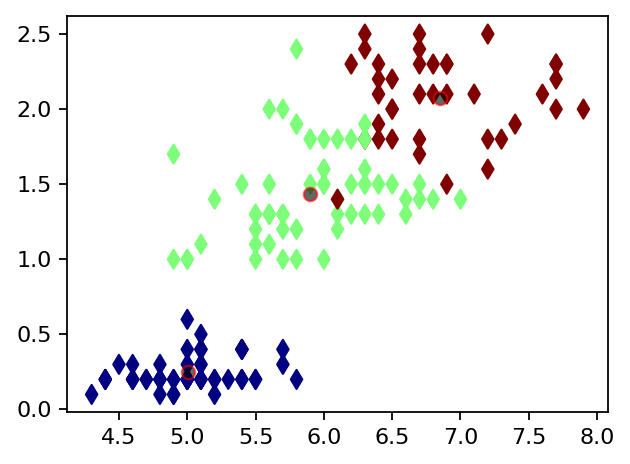

In [46]:
fig = plt.figure(figsize = (4, 3), dpi=160)
plt.scatter(x[:, 0], x[:, 3], c = cluster_ids_x, cmap='jet', marker="d")
plt.scatter(
    cluster_centers[:, 0], cluster_centers[:, 3],
    c='black',
    alpha=0.6,
    edgecolors='red',
    linewidths=1
)
plt.tight_layout()
plt.show()

3.小结

本实例通过花瓣长度、花瓣宽度、花萼长度、花萼宽度4个特征对植物花卉进行分类，经过可视化分析，我们发现花萼特征对我们聚类效果影响更大。运行建模步骤中的代码，模型的聚类结果如下:

In [55]:
cluster_ids_x

tensor([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 2, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1,
        2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 1, 2, 2, 2, 2, 2,
        2, 2, 2, 2, 2, 2])

聚类分析的聚类中心点如下:

In [56]:
cluster_centers

tensor([[1.4620, 0.2460],
        [4.2692, 1.3423],
        [5.5958, 2.0375]])

## 5.3 主成分分析及案例

主成分分析是一个线性变换，它把数据变换到一个新的坐标系统中，使得任何数据投影的第一大方差在第一主成分上，第二大方差在第二主成分上，以此类推。本节介绍使用PyTorch进行主成分分析。

### 5.3.1 主成分分析简介

在统计分析中，为了全面、系统地分析问题，我们必须考虑众多影响因素。这些涉及的因素一般称为指标，在多元统计分析中也称为变量。因为每个变量都在不同程度上反映了所研究问题的某些信息，并且指标之间彼此有一定的相关性，因而所得的统计数据反映的信息在一定程度上有重叠。在用统计方法研究多变量问题时，变量太多会增加计算量和增加分析问题的复杂性，人们希望在进行定量分析的过程中，涉及的变量较少，得到的信息量较多。主成分分析正是适应这一要求产生的，是解决这类问题的理想工具。

主成分分析经常用来减少数据集的维数，同时保持数据集对方差贡献最大的特征。这是通过保留低阶主成分、忽略高阶主成分做到的。这样低阶成分往往能够保留数据最重要的方面。

例如，在对科普书籍开发和利用这一问题的评估中，涉及科普创作人数、科普作品发行量、科普产业化(科普示范基地数)等多项指标。经过对数据进行主成分分析，最后确定几个主成分作为综合评价科普书籍利用和开发的综合指标，变量数减少，并达到一定的可信度，就容易进行科普效果的评估。

### 5.3.2 主成分分析建模

主成分分析是将多个变量通过线性变换以选出较少重要变量的一种多元统计分析方法。主成分分析的思想是将原来众多具有一定相关性的变量重新组合成一组新的互相无关的综合指标来代替原来的指标。它借助一个正交变换，将其分量相关的原随机向量转化成其分量不相关的新随机向量，这在代数上表现为将原随机向量的协方差阵变换成对角形阵，在几何上表现为将原坐标系变换成新的正交坐标系，使之指向样本点散布最开的p个正交方向，然后对多维变量系统进行降维处理。方差较大的几个新变量就能综合反映原多个变量所包含的主要信息，并且也包含自身特殊的含义。主成分分析的数学模型为:

$\begin{align}
z_1 &= u_{11}x_1 + u_{21}x_2 + ··· +u_{p1}x_p\\
z_2 &= u_{12}x_1 + u_{22}x_2 + ··· +u_{p2}x_p\\
···\\
z_p &= u_{1p}x_1 + u_{2p}x_2 + ··· +u_{pp}x_p
\end{align}$

其中，$z_1, z_2,···,z_p$为p个主成分。主成分分析的步骤如下：


1.对原有变量进行坐标变换

$\begin{align}
z_1 &= u_{11}x_1 + u_{21}x_2 + ··· +u_{p1}x_p\\
z_2 &= u_{12}x_1 + u_{22}x_2 + ··· +u_{p2}x_p\\
···\\
z_p &= u_{1p}x_1 + u_{2p}x_2 + ··· +u_{pp}x_p
\end{align}$

其中，参数需要满足如下条件：
$u_{1k}^2+u_{2k}^2+···+u_{pk}^2=1$, $var(z_i)=U_i^2D(x)=U_i^TD(x)U_i$,$cov(z_i,z_j)=U_i^TD(x)U_j$

2.提取主成分

$z_1$称为第一主成分，满足如下条件：
$u_1^Tu_1=1, var(z_1)=max var(u^Tx)$

$z_2$称为第二主成分，满足如下条件：
$cov(z_1,z_2)=0, u_2^Tu_2=1, var(z_1)=max var(u^Tx)$

其余主成分以此类推。

### 5.3.3 动手练习：地区竞争力指标降维

1.说明

衡量我国各省市综合发展情况的一些数据，数据来源于《中国统计年鉴》。数据表中选取了6个指标，分别是人均GDP、固定资产投资、社会消费品零售总额、农村人均纯收入等。下面将利用因子分析来提取公共因子，分析衡量发展因素的指标。

2.步骤

1.导入相关库

In [10]:
import torch
import numpy as np
import pandas as pd
import torch.nn.functional as F
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from torch.autograd import Variable

2.读取数据

In [11]:
region = pd.read_csv("./data/region.csv")
region_d = region[['x1', 'x2', 'x3', 'x4']]
region['target'] = region['y']

In [12]:
region_d

,x1,x2,x3,x4
0,10265,30.81,6235,3223
1,8164,49.13,4929,2406
2,3376,77.76,3921,1668
3,2819,33.97,3305,1206
4,3013,54.51,2863,1208
5,6103,124.02,3706,1756
6,3703,28.65,3174,1609
7,4427,48.51,3375,1766
8,15204,128.93,7191,4245
9,5785,101.09,4634,2456


3.变量特征降维

In [13]:
transfer_1 = PCA(n_components=2)
region_d = transfer_1.fit_transform(region_d)

In [14]:
region_d

array([[ 6.40052716e+03, -1.44272952e+01],
       [ 3.86820619e+03, -6.13122488e+02],
       [-1.02709047e+03,  9.25928127e+00],
       [-1.84066464e+03, -4.34656260e+02],
       [-1.79745246e+03, -9.11365119e+02],
       [ 1.43866958e+03, -1.12498625e+03],
       [-9.70262063e+02, -8.04521195e+02],
       [-2.04059612e+02, -8.47217403e+02],
       [ 1.14877384e+04, -6.97129007e+02],
       [ 1.59958996e+03, -5.29097884e+01],
       [ 2.54522829e+03,  1.36529770e+03],
       [-1.94108734e+03,  1.36574506e+02],
       [ 1.09438719e+03, -9.15271099e+01],
       [-2.14710282e+03, -1.66775033e+02],
       [ 9.97564774e+01, -4.75343880e+01],
       [-2.15301068e+03, -3.17341503e+02],
       [-1.00896943e+03,  2.64755288e+02],
       [-1.46777653e+03,  9.29408192e+02],
       [ 3.06810651e+03,  2.37346735e+03],
       [-1.36911305e+03,  9.93094452e+02],
       [ 5.10696778e+02,  2.79121150e+02],
       [-1.91651782e+03,  3.08927411e+02],
       [-2.84250596e+03,  5.67749040e+02],
       [-1.

In [16]:
x = torch.from_numpy(region_d)
y =torch.from_numpy(np.array(region.target))
x, y = Variable(x), Variable(y)

4.设置网络结构

In [17]:
net =torch.nn.Sequential(
    torch.nn.Linear(2, 10),
    torch.nn.ReLU(),
    torch.nn.Linear(10, 3),
    )
print(net)

Sequential(
  (0): Linear(in_features=2, out_features=10, bias=True)
  (1): ReLU()
  (2): Linear(in_features=10, out_features=3, bias=True)
)


5.设置优化器，随机梯度下降

In [20]:
optimizer = torch.optim.SGD(net.parameters(), lr=0.001)  
loss_func = torch.nn.CrossEntropyLoss()

6.训练模型，并进行可视化

Accuracy=0.69


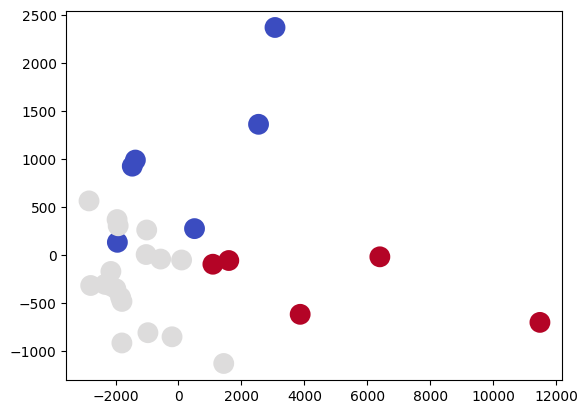

Accuracy=0.66


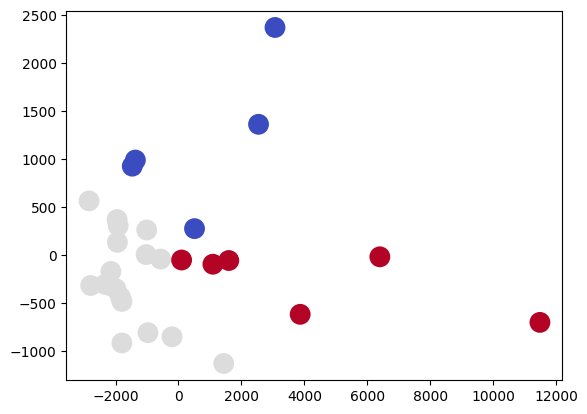

Accuracy=0.66


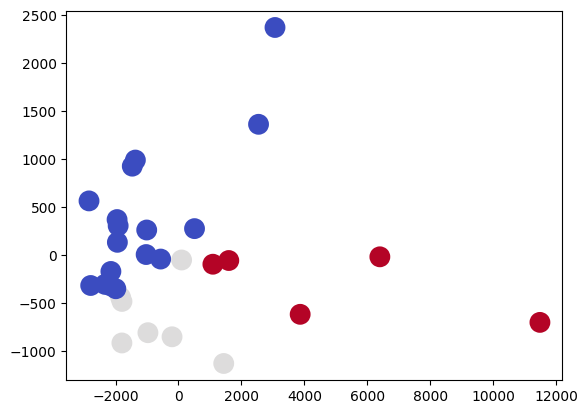

Accuracy=0.76


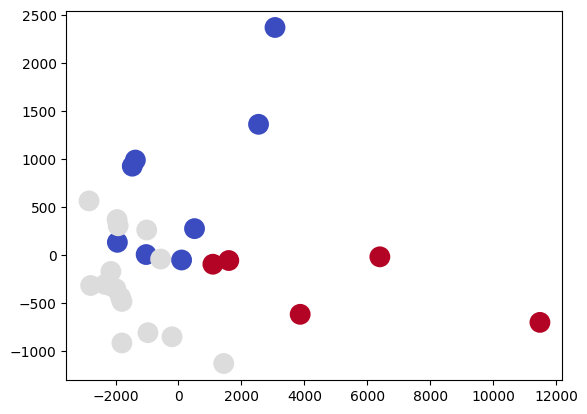

Accuracy=0.79


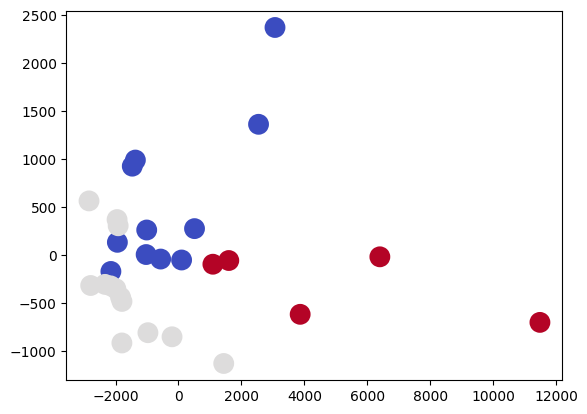

Accuracy=0.69


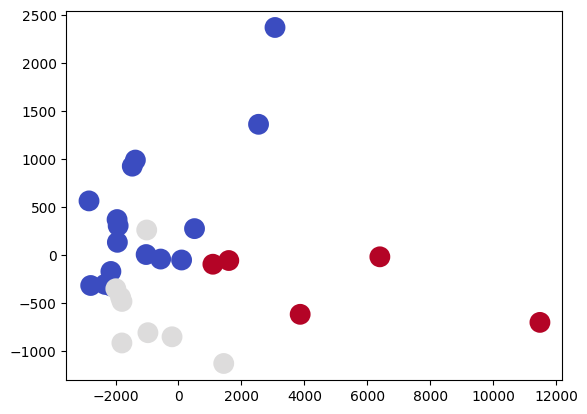

Accuracy=0.79


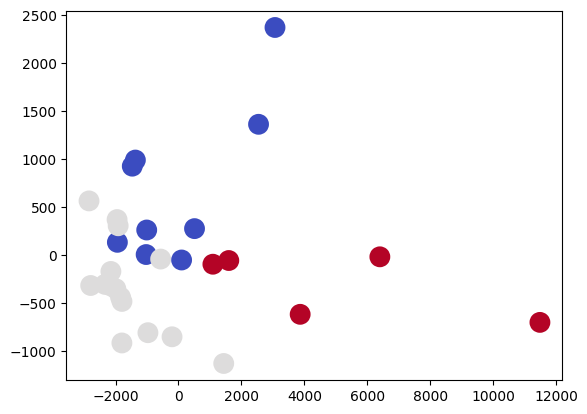

Accuracy=0.69


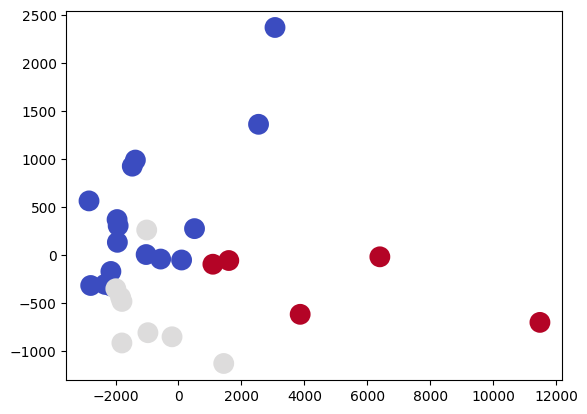

In [22]:
for t in range(2000):
    out = net(x.float())
    loss = loss_func(out, y.long())

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    if t % 250 == 0:
        plt.cla()
        prediction = torch.max(out, 1)[1]
        pred_y = prediction.data.numpy()
        target_y = y.data.numpy()
        plt.scatter(x.data.numpy()[:, 0], x.data.numpy()[:, 1], c=pred_y, s=100, lw=5, cmap='coolwarm')
        accuracy = float((pred_y == target_y).astype(int).sum()) / float(target_y.size)
        print('Accuracy=%.2f' % accuracy)
        plt.pause(0.1)

    plt.show()

## 5.4 模型评估与调优

当我们建立好相关模型以后，怎么评价建立的模型好坏，以及优化建立的模型呢?本节介绍的就是机器学习的模型评估与超参数调优的方法及其案例。

### 5.4.1 模型评估方法

1.混淆矩阵

在机器学习中，正样本就是使模型得出正确结论的例子，负样本就是使模型得出错误结论的例子。比如要从一张猫和狗的图片中检测出狗，那么狗就是正样本，猫就是负样本;反过来，如果想从中检测出猫，那么猫就是正样本，狗就是负样本。

混淆矩阵是机器学习中统计分类模型预测结果的表，它以矩阵形式将数据集中的记录按照真实的类别与分类模型预测的类别进行汇总，其中矩阵的行表示真实值，矩阵的列表示模型的预测值。

下面举一个例子，建立一个二分类的混淆矩阵，假如宠物店有10只动物，其中6只狗、4只猫，现在有一个分类器将这10只动物进行分类，分类结果为5只狗、5只猫，那么我们画出分类结果的混淆矩阵，如下表所示(把狗作为正类)。

![](data/img3.jpeg)

通过混淆矩阵可以计算出真实狗的数量(行相加)为6(5+1)，真实猫的数量为4(0+4)，预测值分类得到狗的数量(列相为5(5+0)，分类得到猫的数量为5(1+4)。

下面介绍几个指标：
* TP (True Positive):被判定为正样本，事实上也是正样本。真的正样本也叫真阳性。
* FN ( False Negative):被判定为负样本，但事实上是正样本。假的负样本也叫假阴性。
* FP ( False Positive):被判定为正样本，但事实上是负样本。假的正样本也叫假阳性。
* TN ( True Negative):被判定为负样本，事实上也是负样本。真的负样本也叫真阴性。

同时，我们不难发现，对于二分类问题，矩阵中的4个元素刚好表示TP、TN、FP、TN这4个指标，如下表所示。

![](data/img4.jpeg)

2.ROC曲线

ROC曲线全称是“受试者工作特征”，通常用来衡量一个二分类学习器的好坏。如果一个学习器的ROC曲线能将另一个学习器的ROC曲线完全包括，则说明该学习器的性能优于另一个学习器。ROC曲线有一个很好的特性:当测试集中的正负样本的分布变化的时候，ROC曲线能够保持不变。

ROC曲线的横轴表示的是FPR，即错误地预测为正例的概率，纵轴表示的是TPR，即正确地预测为正例的概率。二者的计算公式如下:
$FPR=\frac{FP}{FP+TN}$,$TPR=\frac{TP}{TP+FN}$

3.AUC

AUC是一个数值，它是ROC曲线与坐标轴围成的面积。很明显，TPR越大，FPR越小，模型效果就越好，ROC曲线就越靠近左上角，表明模型效果越好，此时AUC值越大，极端情况下为1。由于ROC曲线一般都处于y=x直线的上方，所以AUC的取值范围一般在0.5和1之间。

使用AUC值作为评价标准是因为很多时候ROC曲线并不能清晰地说明哪个分类器的效果更好，而作为一个数值，对应AUC更大的分类器效果更好。与F1-Score不同的是，AUC值并不需要先设定一个阈值。

当然，AUC值越大，当前的分类算法越有可能将正样本排在负样本前面，即能够更好地分类，可以从AUC判断分类器(预测模型)优劣的标准。
* AUC = 1，是完美分类器，采用这个预测模型时，存在至少一个阈值能得出完美预测。绝大多数预测的场合不存在完美分类器。
* 0.5<AUC <1，优于随机猜测。这个分类器(模型)妥善设定阈值的话，能有预测价值。
* AUC = 0.5，跟随机猜测一样，模型没有预测价值。 
* AUC < 0.5，比随机猜测还差。

4.R平方

判定系数R平方，又叫决定系数，是指在线性回归中，回归可解释离差平方和与总离差平方和的比值，其数值等于相关系数R的平方。判定系数是一个解释性系数，在回归分析中，其主要作用是评估回归模型对因变量y产生变化的解释程度，即判定系数R平方是评估回归模型好坏的指标。

R平方取值范围也为0~1，通常以百分数表示。比如回归模型的R平方等于0.7，那么表示，此回归模型对预测结果的可解释程度为70%。一般认为，R平方大于0.75，表示模型拟合度很好，可解释程度较高;R平方小于0.5，表示模型拟合有问题，不宜进行回归分析。

在多元回归实际应用中，判定系数R平方的最大缺陷是:增加自变量的个数时，判定系数就会增加，即随着自变量的增多，R平方会越来越大，会显得回归模型精度很高，有较好的拟合效果。而实际上可能并非如此，有些自变量与因变量完全不相关，增加这些自变量并不会提升拟合水平和预测精度。

为了解决这个问题，即避免增加自变量而高估R平方，需要对R平方进行调整。采用的方法是用样本量n和自变量的个数k去调整R平方，调整后的R平方的计算公式如下:$1-(1-R^2)\frac{(n-1)}{n-k-1}$。

从公式可以看出，调整后的R平方同时考虑了样本量(n)和回归中自变量的个数(k)的影响，这使得调整后的R平方永远小于R平方，并且调整后的R平方的值不会由于回归中自变量个数的增加而越来越接近1。

因调整后的R平方较R平方测算更准确，在回归分析尤其是多元回归中，我们通常使用调整后的R平方对回归模型进行精度测算，以评估回归模型的拟合度和效果。一般认为，在回归分析中，0.5为调整后的R平方的临界值，如果调整后的R平方小于0.5，则要分析我们所采用和未采用的自变量。如果调整后的R平方与R平方存在明显差异，则意味着所用的自变量不能很好地测算因变量的变化，或者是遗漏了一些可用的自变量。如果调整后的R平方与原来的R平方之间的差距越大，那么模型的拟合效果就越差。

5.残差

残差在数理统计中是指实际观察值与估计值(拟合值)之间的差，它蕴含了有关模型基本假设的重要信息。如果回归模型正确的话，我们可以将残差看作是误差的观测值。

通常，回归算法的残差评价指标有均方误差(Mean SquaredError, MSE)、均方根误差(Root Mean Squard Error, RMSE)、平均绝对误差(Mean Absolute Error, MAE)3个。

(1)均方误差

均方误差表示预测值和观测值之间差异(残差平方)的平均值，公式如下:$MSE = \frac{1}{m}\sum _{i=1}^m(y_i-\hat y_i)^2$,即真实值减去预测值，然后平方再求和，最后求平均值。这个公式其实就是线性回归的损失函数，在线性回归中，我们的目的就是让这个损失函数的数值最小。

(2)均方根误差

均方根误差表示预测值和观测值之间差异(残差)的样本标准差，公式如下:$RMSE = \sqrt{MSE}$,即均方误差的平方根，均方根误差是有单位的，与样本数据是一样。

(3)平均绝对误差

平均绝对误差表示预测值和观测值之间绝对误差的平均值，公式如下:$MAE = \frac{1}{m}\sum_{i=1}^m|y_i-\hat y_i|$, MAE是一种线性分数，所有个体差异在平均值上的权重都相等，而RMSE相比MAE，会对高的差异惩罚更多。

### 5.4.2 模型调优方法

1.交叉验证

交叉验证也称为循环估计，是一种统计学上将数据样本切割成较小子集的实用方法，主要应用于数据建模。交叉验证的基本思想:将原始数据进行分组，一部分作为训练集，另一部分作为验证集，首先用训练集对模型进行训练，再利用验证集来测试训练得到的模型，以此作为评价模型的性能指标，用交叉验证的目的是为了得到可靠稳定的模型。

交叉验证的常见方法如下:

(1) Holdout验证

将原始数据随机分为两组，一组作为训练集，另一组作为测试集，利用训练集训练模型，然后利用测试集验证模型，记录最后的模型准确率，以此作为模型的性能指标。

(2)K折交叉验证

初始采样分割成K个子样本，一个单独的子样本被保留作为验证模型的数据，其他K-1个样本用来训练。交叉验证重复K次，每个子样本验证一次，平均K次的结果或者使用其他结合方式，最终得到一个单一估测。这个方法的优势在于，同时重复运用随机产生的子样本进行训练和验证，每次的结果验证一次。

(3)留一验证

留一验证指只使用原本样本中的一项来当验证数据，而剩余的则留下当训练数据。这个步骤一直持续到每个样本都被当一次验证数据。事实上，这等同于和K折交叉验证，其中K为原样本个数。

(4)十折交叉验证

十折交叉验证用来测试算法的准确性，是常用的测试方法。将数据集分成10份，轮流将其中9份作为训练数据，1份作为测试数据。每次试验都会得出相应的正确率。10次结果的正确率的平均值作为算法精度的估计，一般还需要进行多次十折交叉验证(例如10次十折交叉验证)，再求其均值，作为算法的最终准确性估计。

2.GridSearchCV

通常情况下，有部分机器学习算法中的参数是需要手动指定的(如k近邻算法中的K值)，这种叫超参数。但是手动设置过程繁杂，需要对模型预设几种超参数组合，每组超参数都采用交叉验证来进行评估，最后挑选出最优参数组合。网格搜索法就可以自动调整至最佳参数组合。GridSearchCV可以拆分为两部分，即网格搜索(GridSearch)和交叉验证(CV)。网格搜索搜索的是参数，即在指定的参数范围内按步长依次调整参数，利用调整的参数训练模型，从所有的参数中找到在验证集上精度最高的参数，这其实是一个训练和比较的过程。

网格搜索可以保证在指定的参数范围内找到精度最高的参数，但是这也是网格搜索的缺陷所在，它要求遍历所有可能参数的组合，在面对大数据集和多参数的情况下，非常耗时。所以网格搜索适用于三四个(或者更少)超参数，用户列出一个较小的超参数值域，这些超参数值域的笛卡尔积为一组超参数。

3.随机搜索

我们在搜索超参数的时候，如果超参数个数较少，例如三四个或者更少，那么就可以采用网格搜索，这一种穷尽式的搜索方法。但是当超参数个数比较多的时候，如果仍然采用网格搜索，那么搜索所需的时间将会呈现指数上升。所以就提出了随机搜索的方法，随机在超参数空间中搜索几十甚至几百个点，其中就有可能有比较小的值。随机搜索的使用方法与网格搜索很相似，但它不是尝试所有可能的组合，而是选择每个超参数的一个随机值的特定数量的随机组合，这样可以方便地通过设定搜索次数控制超参数搜索的计算量等。对于有连续变量的参数，随机搜索会将其当成一个分布进行采样，这是网格搜索做不到的。

### 5.4.3 动手练习:PyTorch实现交叉验证

1.说明

本例使用PyTorch实现交叉验证，以十折交叉验证为例，也就是将数据分成10组，进行10组训练，每组用于测试的数据为:数据总条数/组数，每次测试的数据都是随机抽取的。

2.步骤

具体操作步骤如下:

1.导入相关第三方库

In [23]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.autograd import Variable
from torch.utils.data import DataLoader, Dataset

2.构造训练集

In [24]:
x = torch.rand(100,28,28) 
y = torch.randn(100,28,28)
x = torch.cat((x,y),dim=0)
label =[1] *100 + [0]*100  
label = torch.tensor(label,dtype=torch.long)

3.设置网络结构

In [25]:
class Net(nn.Module):
    def __init__(self):
        super(Net, self).__init__() 
        self.fc1  = nn.Linear(28*28, 120) 
        self.fc2  = nn.Linear(120, 84)
        self.fc3  = nn.Linear(84, 2)
  
    def forward(self, x):
        x = x.view(-1, self.num_flat_features(x))
        x = F.relu(self.fc1(x)) 
        x = F.relu(self.fc2(x)) 
        x = self.fc3(x) 
        return x
    
    def num_flat_features(self, x):
        size = x.size()[1:] 
        num_features = 1
        for s in size:
            num_features *= s
        return num_features

4.训练集数据处理

In [26]:
class TraindataSet(Dataset):
    def __init__(self,train_features,train_labels):
        self.x_data = train_features
        self.y_data = train_labels
        self.len = len(train_labels)
    
    def __getitem__(self,index):
        return self.x_data[index],self.y_data[index]
        
    def __len__(self):
        return self.len

5.设置损失函数

In [27]:
loss_func = nn.CrossEntropyLoss()

6.设置k折划分

In [28]:
def get_k_fold_data(k, i, X, y):
    assert k > 1
    fold_size = X.shape[0] // k
    X_train, y_train = None, None
    
    for j in range(k):
        idx = slice(j * fold_size, (j + 1) * fold_size)
        X_part, y_part = X[idx, :], y[idx]
        if j == i:
            X_valid, y_valid = X_part, y_part
        elif X_train is None:
            X_train, y_train = X_part, y_part
        else:
            X_train = torch.cat((X_train, X_part), dim=0)
            y_train = torch.cat((y_train, y_part), dim=0)
    
    return X_train, y_train, X_valid, y_valid

def k_fold(k, X_train, y_train, num_epochs = 3,learning_rate = 0.001, weight_decay = 0.1, batch_size = 5):
    train_loss_sum, valid_loss_sum = 0, 0
    train_acc_sum, valid_acc_sum = 0, 0
    
    for i in range(k):
        data = get_k_fold_data(k, i, X_train, y_train)
        net =  Net()
        train_ls, valid_ls = train(net, *data, num_epochs, learning_rate, weight_decay, batch_size) 
       
        print('*'*10,'第',i+1,'折','*'*10)
        print('训练集损失:%.6f'%train_ls[-1][0],'训练集准确度:%.4f'%valid_ls[-1][1],\
              '测试集损失:%.6f'%valid_ls[-1][0],'测试集准确度:%.4f'%valid_ls[-1][1])
        train_loss_sum += train_ls[-1][0]
        valid_loss_sum += valid_ls[-1][0]
        train_acc_sum += train_ls[-1][1]
        valid_acc_sum += valid_ls[-1][1]
        
    print('#'*5,'最终k折交叉验证结果','#'*5)
    print('训练集累积损失:%.4f'%(train_loss_sum/k),'训练集累积准确度:%.4f'%(train_acc_sum/k),\
          '测试集累积损失:%.4f'%(valid_loss_sum/k),'测试集累积准确度:%.4f'%(valid_acc_sum/k))

7.设置训练函数

In [32]:
def train(net, train_features, train_labels, test_features, test_labels, num_epochs, learning_rate,weight_decay, batch_size):
    train_ls, test_ls = [], []
    dataset = TraindataSet(train_features, train_labels) 
    train_iter = DataLoader(dataset, batch_size, shuffle=True)
    
    optimizer = torch.optim.Adam(params=net.parameters(), lr = learning_rate, weight_decay = weight_decay)
    
    for epoch in range(num_epochs):
        for X, y in train_iter:
            output  = net(X)
            loss = loss_func(output, y)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
       
        train_ls.append(log_rmse(0, net, train_features, train_labels)) 
        if test_labels is not None:
            test_ls.append(log_rmse(1, net, test_features, test_labels))

    return train_ls, test_ls

In [33]:
def log_rmse(flag,net,x,y):
    if flag == 1:
        net.eval()
    output = net(x)
    result = torch.max(output,1)[1].view(y.size())
    corrects = (result.data == y.data).sum().item()
    accuracy = corrects*100.0/len(y)
    loss = loss_func(output,y)
    net.train()
    
    return (loss.data.item(),accuracy)

In [35]:
k_fold(10, x, label)

********** 第 1 折 **********
训练集损失:0.041206 训练集准确度:100.0000 测试集损失:0.019765 测试集准确度:100.0000
********** 第 2 折 **********
训练集损失:0.037590 训练集准确度:100.0000 测试集损失:0.028711 测试集准确度:100.0000
********** 第 3 折 **********
训练集损失:0.040640 训练集准确度:100.0000 测试集损失:0.026640 测试集准确度:100.0000
********** 第 4 折 **********
训练集损失:0.037502 训练集准确度:100.0000 测试集损失:0.026673 测试集准确度:100.0000
********** 第 5 折 **********
训练集损失:0.043892 训练集准确度:100.0000 测试集损失:0.021362 测试集准确度:100.0000
********** 第 6 折 **********
训练集损失:0.039145 训练集准确度:85.0000 测试集损失:0.476621 测试集准确度:85.0000
********** 第 7 折 **********
训练集损失:0.036531 训练集准确度:95.0000 测试集损失:0.382741 测试集准确度:95.0000
********** 第 8 折 **********
训练集损失:0.041698 训练集准确度:100.0000 测试集损失:0.331184 测试集准确度:100.0000
********** 第 9 折 **********
训练集损失:0.039798 训练集准确度:100.0000 测试集损失:0.308953 测试集准确度:100.0000
********** 第 10 折 **********
训练集损失:0.037052 训练集准确度:85.0000 测试集损失:0.480882 测试集准确度:85.0000
##### 最终k折交叉验证结果 #####
训练集累积损失:0.0395 训练集累积准确度:100.0000 测试集累积损失:0.2104 测试集累积准确度:96.5000
